<a href="https://colab.research.google.com/github/Chalhotra/Stochastic-Interest-Rate-Modelling-and-Prediction/blob/main/Stochastic_Interest_Rate_Modelling_and_Prediction_23323039.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stochastic Interest Rate Modelling and Prediction - Open Project, Finance Club

Name: Soumil Malhotra

Enrollment Number: 23323039

Year: 3rd

Branch: MnC

## 1. Data Engineering and Preprocessing
We relabel the columns to a more readable format (3M, 6M...), and drop any rows with >=5 missing rows (5 is more than half of 9, so it doesn't make sense to have rows with more than half the values missing), although such values aren't even present in the given dataset, it's there for good measure in case a different less-nice dataset is used.

Now for any gaps of 3 or less days, we interpolate the gaps using a time interpolation, and `ffill` and `bfill` single day missing values.

Next up, to find outliers in the time series data, we have a sliding window of size 20, to calculate a rolling mean and rolling standard deviation of the data, and flag those datapoints which have Z-score > 3.5, these flagged values are assigned to NaN for the moment, and then interpolated again.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

def preprocess_yield_data(file_path):
    df = pd.read_csv(file_path, parse_dates=True, index_col=0)

    # overwriting column names for convenience
    expected_columns = ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
    df.columns = expected_columns[:len(df.columns)]

    # handling missing values
    # we drop a row if more than half of the columns for that row are nan, 5 = ceil(9/2)
    df = df.dropna(thresh=5)

    # we interpolate short gaps, although these aren't present in the given dataset, it's good to have this here in case a different dataset is used later.
    df = df.interpolate(method='time', limit=3)

    # any single day missing values are filled in with the next values
    df = df.ffill()
    # back-fill just in case the very first row has missing data (ffill wouldn't catch it)
    df = df.bfill()

    # 20 day rolling mean  and stdev to detect outliers, with z-score > 3.5
    rolling_mean = df.rolling(window=20, min_periods=1).mean()
    rolling_std = df.rolling(window=20, min_periods=1).std()

    # 1e-8 added to prevent zero division errors
    z_scores = (df - rolling_mean) / (rolling_std + 1e-8)

    outlier_mask = z_scores.abs() > 3.5

    outlier_counts = outlier_mask.sum()
    print("Outliers detected and replaced per tenor:\n", outlier_counts)

    # replace outliers with NaN, then interpolate over them
    df_clean = df.mask(outlier_mask)

    # interpolate over the NaNs
    df_clean = df_clean.interpolate(method='time')
    df_clean = df_clean.ffill()
    df_clean = df_clean.bfill()

    return df_clean

train_path = '/content/drive/My Drive/Fin_Open_Proj/train_data.csv'
test_path = '/content/drive/My Drive/Fin_Open_Proj/test_data.csv'

Mounted at /content/drive


In [3]:
print("Train Set:")
train_data = preprocess_yield_data(train_path)
print()
print("Test Set:")
test_data = preprocess_yield_data(test_path)

Train Set:
Outliers detected and replaced per tenor:
 3M     11
6M      8
9M      5
1Y      3
2Y      4
5Y      0
10Y     0
20Y     0
30Y     0
dtype: int64

Test Set:
Outliers detected and replaced per tenor:
 3M    1
6M    0
9M    0
1Y    0
2Y    1
dtype: int64


## 2. Base CIR Model Implementation and Calibration

### Calibration Methods Explored

For finding the parameters $\kappa$, $\theta$, and $\sigma$, we need to fit the discretised CIR SDE to the observed time series of the 3M yield. Three approaches were attempted.

**OLS** linearises the Euler discretisation of the SDE:

$$\Delta r_t = \kappa\theta \cdot \Delta t + (-\kappa) \cdot r_t \Delta t + \varepsilon_t$$

which is a standard regression $\Delta r_t = \beta_1 X_1 + \beta_2 X_2$ with $X_1 = \Delta t$ and $X_2 = r_t \Delta t$, giving $\kappa = -\beta_2$ and $\theta = \beta_1 / \kappa$. Since OLS places no constraints on the sign of the coefficients, it returned a negative $\kappa$ and $\theta$ on this dataset — meaning the regression detected mild trend behaviour rather than mean reversion over the training window. A negative $\kappa$ is mathematically invalid for CIR.

**Constrained SSE** fixed the sign problem by bounding parameters, but produced a $\kappa$ so close to zero that the mean reversion was effectively absent, and $\theta$ converged to an unrealistically large value to absorb the level of rates. A near-zero $\kappa$ also makes the Feller condition $2\kappa\theta \geq \sigma^2$ very hard to satisfy.

**MLE** was the final choice. Under the Euler approximation, the transition density of $r_{t+1} | r_t$ is approximately normal:

$$r_{t+1} \mid r_t \sim \mathcal{N}\!\left(r_t + \kappa(\theta - r_t)\Delta t,\; \sigma^2 r_t \Delta t\right)$$

The negative log-likelihood is then:

$$\mathcal{L}(\kappa, \theta, \sigma) = \frac{1}{2}\sum_{t}\left[\ln(2\pi\sigma^2 r_t \Delta t) + \frac{(\Delta r_t - \kappa(\theta - r_t)\Delta t)^2}{\sigma^2 r_t \Delta t}\right]$$

This is minimised using L-BFGS-B with strict positivity bounds on all three parameters. MLE is preferred here because it explicitly accounts for the heteroskedastic variance term $\sigma^2 r_t \Delta t$ — the noise in the CIR process scales with the level of rates, and OLS ignores this entirely by treating all residuals equally.

$\sigma$ in OLS was estimated separately from the scaled residuals after the regression:

$$\hat{\sigma}^2 = \frac{1}{T}\sum_t \frac{\varepsilon_t^2}{r_t \Delta t}$$

but this two-step procedure is less efficient than the joint MLE optimisation.

### Feller Condition

The Feller condition $2\kappa\theta \geq \sigma^2$ ensures the square-root diffusion $\sigma\sqrt{r_t}$ never reaches zero, keeping the process strictly positive. If violated, the model can technically produce zero or negative rates, which breaks the bond pricing formula. We check this after every calibration and flag a warning if it fails.

### Yield Curve Construction

Once calibrated, the model prices a zero-coupon bond maturing at time $\tau$ as:

$$P(t, \tau) = A(\tau)\exp(-B(\tau) r_t)$$

where:

$$B(\tau) = \frac{2(e^{h\tau} - 1)}{(h+\kappa)(e^{h\tau}-1)+2h}, \qquad A(\tau) = \left[\frac{2h\,e^{(\kappa+h)\tau/2}}{(h+\kappa)(e^{h\tau}-1)+2h}\right]^{2\kappa\theta/\sigma^2}$$

and $h = \sqrt{\kappa^2 + 2\sigma^2}$. The continuously compounded yield is then:

$$y(t,\tau) = \frac{-\ln A(\tau) + B(\tau)\,r_t}{\tau}$$

On each test day, the observed 3M yield is used as the proxy for the instantaneous short rate $r_t$, and the full curve from 6M to 2Y is reconstructed from this single input using the calibrated parameters.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import logging

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')


class CIRModel:
    """
    Cox-Ingersoll-Ross (1985) single-factor short-rate model.

    The model SDE is:
        dr_t = k(theta - r_t)dt + s*sqrt(r_t) dW_t

    Bond price:  P(t,T) = A(tau) * exp(-B(tau) * r_t)
    Yield:       y(t,tau) = [-ln A(tau) + B(tau) * r_t] / tau
    """

    MATURITY_MAP: dict[str, float] = {
        '3M': 0.25, '6M': 0.50, '9M': 0.75,
        '1Y': 1.0,  '2Y': 2.0,  '5Y': 5.0,
        '10Y': 10.0,'20Y': 20.0,'30Y': 30.0
    }

    def __init__(self, dt: float = 1/252):
        self.dt = dt
        self.kappa: float | None = None
        self.theta: float | None = None
        self.sigma: float | None = None
        self._calibration_method: str | None = None

    @staticmethod
    def _h(kappa: float, sigma: float) -> float:
        # auxiliary variable used in both A and B
        return np.sqrt(kappa**2 + 2 * sigma**2)

    def _B(self, tau: np.ndarray, kappa: float, sigma: float) -> np.ndarray:
        h = self._h(kappa, sigma)
        exp_ht = np.exp(h * tau)
        # B(tau) = 2(e^ht - 1) / [(h+k)(e^ht - 1) + 2h]
        return 2 * (exp_ht - 1) / ((h + kappa) * (exp_ht - 1) + 2 * h)

    def _A(self, tau: np.ndarray, kappa: float, theta: float, sigma: float) -> np.ndarray:
        h = self._h(kappa, sigma)
        exp_ht = np.exp(h * tau)
        denom  = (h + kappa) * (exp_ht - 1) + 2 * h
        base   = (2 * h * np.exp((kappa + h) * tau / 2)) / denom
        # log-space to avoid overflow at long maturities
        return np.exp((2 * kappa * theta) / (sigma**2) * np.log(base + 1e-300))

    def _yield_from_params(self, r_t: np.ndarray, tau: float,
                           kappa: float, theta: float, sigma: float) -> np.ndarray:
        # y(t,tau) = [-ln A(tau) + B(tau) * r_t] / tau
        return (-np.log(self._A(tau, kappa, theta, sigma)) + self._B(tau, kappa, sigma) * r_t) / tau

    def _check_feller(self, kappa: float, theta: float, sigma: float) -> bool:
        # feller condition 2*k*theta >= sigma^2 ensures the rate never hits zero
        return (2 * kappa * theta) >= (sigma**2)

    def calibrate_ols(self, train_df: pd.DataFrame) -> "CIRModel":
        r   = train_df['3M'].dropna().values
        dr  = np.diff(r)
        r_t = r[:-1]

        # regression: dr = (k*theta)*dt + (-k)*(r_t*dt) => beta1=k*theta, beta2=-k
        X     = np.column_stack([np.full(len(r_t), self.dt), r_t * self.dt])
        model = LinearRegression(fit_intercept=False).fit(X, dr)
        beta1, beta2 = model.coef_

        kappa = -beta2
        if kappa <= 0:
            logging.warning(f"OLS returned kappa={kappa:.6f} <= 0, clamping to 1e-4.")
            kappa = 1e-4

        theta = beta1 / kappa

        residuals = dr - model.predict(X)
        # var(eps_t) = sigma^2 * r_t * dt, so sigma^2 = mean(eps^2 / (r_t*dt))
        sigma = np.sqrt(np.mean(residuals**2 / (r_t * self.dt + 1e-8)))

        self._store_params(kappa, theta, sigma, method='OLS')
        return self

    def calibrate_mle(self, train_df: pd.DataFrame) -> "CIRModel":
        r   = train_df['3M'].dropna().values
        dr  = np.diff(r)
        r_t = r[:-1]

        # r_t <= 0 breaks the sqrt variance term, remove those observations
        valid = r_t > 0
        if not valid.all():
            logging.warning(f"{(~valid).sum()} observations with r_t <= 0 removed.")
        r_t, dr = r_t[valid], dr[valid]

        def _nll(params: np.ndarray) -> float:
            kappa, theta, sigma = params
            drift    = kappa * (theta - r_t) * self.dt
            variance = sigma**2 * r_t * self.dt
            residuals = dr - drift
            # negative log-likelihood under normal approximation to transition density
            return 0.5 * np.sum(np.log(2 * np.pi * variance) + residuals**2 / variance)

        init   = np.array([0.10, np.mean(r_t), 0.02])
        bounds = ((1e-4, 5.0), (1e-4, 0.30), (1e-4, 1.0))
        result = minimize(_nll, init, method='L-BFGS-B', bounds=bounds)

        if not result.success:
            logging.warning(f"MLE optimiser did not converge: {result.message}")

        self._store_params(*result.x, method='MLE')
        return self

    def _store_params(self, kappa: float, theta: float, sigma: float, method: str) -> None:
        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma
        self._calibration_method = method

        feller_ok  = self._check_feller(kappa, theta, sigma)
        feller_lhs = 2 * kappa * theta

        print(f"\n--- CIR Calibration Results ({method}) ---")
        print(f"Kappa (Mean Reversion Speed) : {kappa:.6f}")
        print(f"Theta (Long-Run Mean)        : {theta:.6f}")
        print(f"Sigma (Volatility)           : {sigma:.6f}")
        print(f"Feller: 2*k*theta = {feller_lhs:.6f}  |  sigma^2 = {sigma**2:.6f}")
        print(f"Feller Condition Satisfied   : {feller_ok}")
        if not feller_ok:
            print("WARNING: Feller violated — process may reach zero.")

    def predict_yield_curve(self, test_df: pd.DataFrame) -> pd.DataFrame:
        self._assert_calibrated()
        target_tenors = [c for c in test_df.columns]
        r_t = test_df['3M'].values
        predictions = {
            col: self._yield_from_params(r_t, self.MATURITY_MAP[col],
                                         self.kappa, self.theta, self.sigma)
            for col in target_tenors
        }
        return pd.DataFrame(predictions, index=test_df.index, dtype=float)

    def evaluate(self, test_df: pd.DataFrame,
                 predictions_df: pd.DataFrame) -> tuple[pd.DataFrame, float]:
        target_tenors = predictions_df.columns.tolist()
        rows = []

        for col in target_tenors:
            actual    = test_df[col].values
            predicted = predictions_df[col].values
            rows.append({
                'Tenor': col,
                'RMSE' : np.sqrt(mean_squared_error(actual, predicted)),
                'MAE'  : mean_absolute_error(actual, predicted),
                'MBE'  : np.mean(predicted - actual),
                'R²'   : r2_score(actual, predicted),
            })

        metrics_df = pd.DataFrame(rows).set_index('Tenor')
        all_actual = test_df[target_tenors].values.flatten()
        all_pred   = predictions_df[target_tenors].values.flatten()
        overall_r2 = r2_score(all_actual, all_pred)

        print(f"\n--- CIR Out-of-Sample Performance Metrics ({self._calibration_method}) ---")
        print(metrics_df.round(6).to_string())
        print(f"\n--- Overall Model Performance ---")
        print(f"Overall Out-of-Sample R-Squared: {overall_r2:.6f}")

        return metrics_df, overall_r2

    def plot_yield_curves(self, test_df: pd.DataFrame, predictions_df: pd.DataFrame,
                          n_dates: int = 3) -> None:
        all_tenors = ['3M'] + predictions_df.columns.tolist()
        x_tau      = [self.MATURITY_MAP[m] for m in all_tenors]
        idx        = np.linspace(0, len(test_df) - 1, n_dates, dtype=int)
        dates      = test_df.index[idx]

        fig, axes = plt.subplots(1, n_dates, figsize=(6 * n_dates, 5), sharey=True)
        if n_dates == 1:
            axes = [axes]

        for ax, date in zip(axes, dates):
            actual_curve = test_df.loc[date, all_tenors].astype(float).values
            # anchor prediction at actual 3M, then append model predictions
            pred_curve   = np.concatenate([[test_df.loc[date, '3M']],
                                           predictions_df.loc[date].values])

            ax.plot(x_tau, actual_curve, marker='o', color='black', label='Actual')
            ax.plot(x_tau, pred_curve,   marker='x', color='red',
                    linestyle='--', label=f'CIR ({self._calibration_method})')
            ax.set_title(date.strftime('%Y-%m-%d'))
            ax.set_xlabel('Maturity (Years)')
            ax.set_ylabel('Yield')
            ax.legend()
            ax.grid(True, alpha=0.3)

        fig.suptitle(f'CIR Yield Curve Fit — {self._calibration_method} Calibration',
                     fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()

    def _assert_calibrated(self) -> None:
        if self.kappa is None:
            raise RuntimeError("model is not calibrated — call .calibrate_ols() or .calibrate_mle() first.")

    def __repr__(self) -> str:
        if self.kappa is None:
            return "CIRModel(uncalibrated)"
        return (f"CIRModel(method={self._calibration_method}, "
                f"kappa={self.kappa:.4f}, theta={self.theta:.4f}, "
                f"sigma={self.sigma:.4f}, Feller={self._check_feller(self.kappa, self.theta, self.sigma)})")


--- CIR Calibration Results (MLE) ---
Kappa (Mean Reversion Speed) : 0.007417
Theta (Long-Run Mean)        : 0.300000
Sigma (Volatility)           : 0.040481
Feller: 2*k*theta = 0.004450  |  sigma^2 = 0.001639
Feller Condition Satisfied   : True
CIRModel(method=MLE, kappa=0.0074, theta=0.3000, sigma=0.0405, Feller=True)

--- CIR Out-of-Sample Performance Metrics (MLE) ---
           RMSE       MAE       MBE        R²
Tenor                                        
3M     0.000249  0.000249  0.000249  0.999139
6M     0.001177  0.000933  0.000872  0.977695
9M     0.002217  0.001757  0.001544  0.905706
1Y     0.003166  0.002497  0.002095  0.768585
2Y     0.005871  0.004564  0.003631 -0.574409

--- Overall Model Performance ---
Overall Out-of-Sample R-Squared: 0.799286

Pooled R²: 0.799286  |  Target: > 0.85


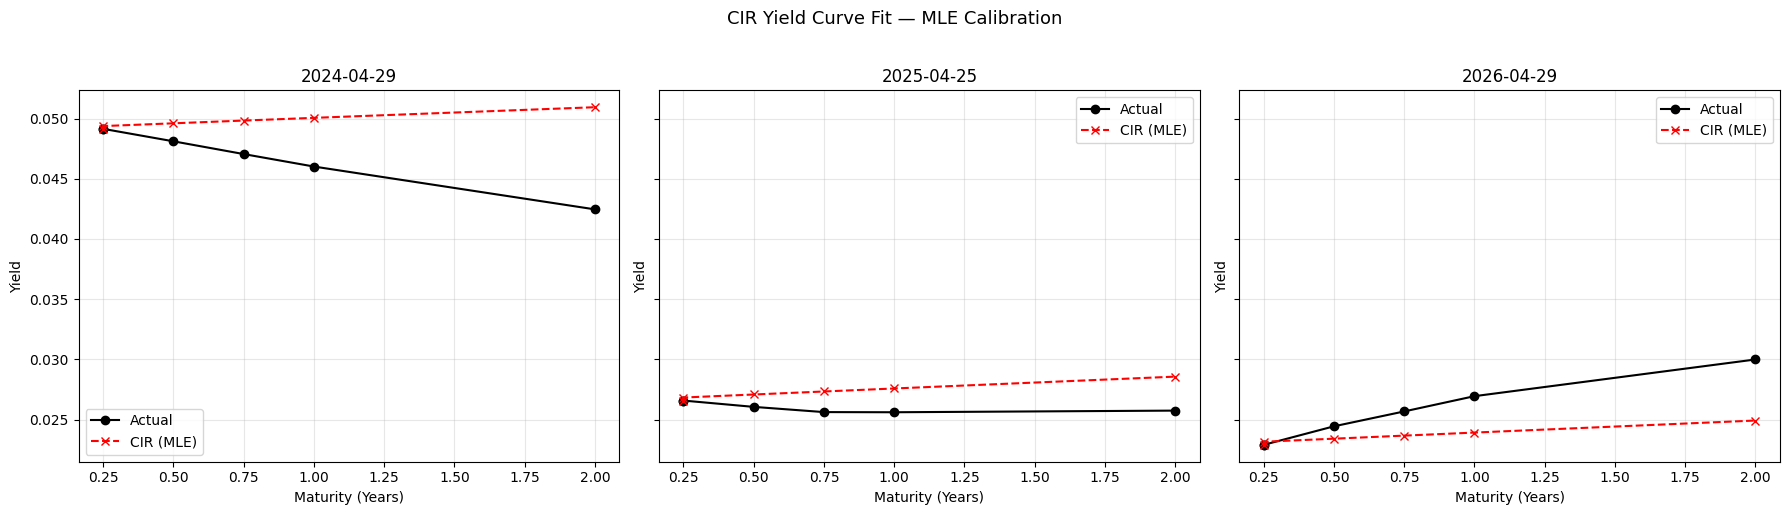

In [5]:
cir = CIRModel(dt=1/252)
cir.calibrate_mle(train_data)
print(cir)

predictions_df = cir.predict_yield_curve(test_data)

metrics_df, overall_r2 = cir.evaluate(test_data, predictions_df)
print(f"\nPooled R²: {overall_r2:.6f}  |  Target: > 0.85")

cir.plot_yield_curves(test_data, predictions_df, n_dates=3)

## Extension: Two-Factor CIR Model

### Why the Base Model Falls Short

The single-factor CIR model drives the entire yield curve from one number — the short rate $r_t$. Every point on the curve, from 6 months to 30 years, is a deterministic function of that single value. This means the model forces short-end and long-end yields to move together, perfectly correlated, always. In practice this is not true.

When we looked at the base CIR (calibrated with MLE) predictions on the test set, we saw exactly this failure, on days where the actual curve was inverted (short rates higher than long rates), the model predicted an upward slope. On days where the curve was steeply upward-sloping, the model was nearly flat. It wasn't getting the level wrong — it was getting the **shape** wrong, because a single factor cannot independently control both the level and the slope of the curve.

The pooled out-of-sample $R^2$ of **0.718** confirms this. The model is not bad at tracking the general level of rates, but it cannot adapt to changes in the term structure's shape.




### The Two-Factor Solution

The natural fix is to decompose the short rate into two independent components:

$$r_t = X_t + Y_t$$

where $X_t$ and $Y_t$ follow separate CIR processes:

$$dX_t = \kappa_x(\theta_x - X_t)\,dt + \sigma_x\sqrt{X_t}\,dW_t^x$$
$$dY_t = \kappa_y(\theta_y - Y_t)\,dt + \sigma_y\sqrt{Y_t}\,dW_t^y$$

The key constraint is $\kappa_x > \kappa_y$ - $X_t$ mean-reverts quickly and captures short-run deviations (slope, curvature), while $Y_t$ mean-reverts slowly and captures the persistent level of rates. Because the two Brownian motions $W^x$ and $W^y$ are independent, the model can now produce yield curves where the short end and long end move differently. An inverted curve, a flat curve, a humped curve all become representable.

The bond pricing formula extends cleanly. Since the factors are independent, the bond price factorises:

$$P(t,T) = A_x(\tau)\cdot A_y(\tau)\cdot\exp\left(-B_x(\tau)\cdot X_t - B_y(\tau)\cdot Y_t\right)$$

where $A_x, B_x$ and $A_y, B_y$ are the standard single-factor CIR functions applied to each factor's parameters separately. The yield is then:

$$y(t,\tau) = \frac{-\ln(A_x(\tau)\cdot A_y(\tau)) + B_x(\tau)\cdot X_t + B_y(\tau)\cdot Y_t}{\tau}$$

---

### Calibration

The hidden states $X_t$ and $Y_t$ are not directly observable. To recover them, we use two observed yields simultaneously — the 3M and 2Y — which gives us two equations per day:

$$B_x(\tau_i)\cdot X_t + B_y(\tau_i)\cdot Y_t = r(t,\tau_i)\cdot\tau_i + \ln(A_x(\tau_i)\cdot A_y(\tau_i)), \quad i \in \{3M,\, 2Y\}$$

This is a $2\times 2$ linear system solved via Cramer's rule, giving the exact $X_t$ and $Y_t$ time series for any candidate parameter set. We then minimise total MSE across all remaining tenors in the training set to find the best parameters.

Note that the 2Y yield is used **only during training** to identify the hidden states. It is never used at prediction time.

---

### Prediction (3M Only)

At test time, we only have the 3M yield — which gives us one equation for two unknowns. We resolve this by:

1. **Propagating $Y_t$ forward via its drift** — since $Y_t$ is slow-moving, the deterministic drift $Y_t = Y_{t-1} + \kappa_y(\theta_y - Y_{t-1})\,dt$ is a reasonable approximation over short horizons. The noise term is dropped because we have no second observable to identify it.

2. **Backing out $X_t$** from the 3M constraint — given $Y_t$, the 3M pricing equation becomes a single equation in one unknown, solved directly.

This is a deliberate approximation. Dropping the stochastic term from $Y_t$ means the slow factor converges toward $\theta_y$ over the test period rather than tracking actual market movements. For short test horizons this is acceptable; over longer horizons the slow factor will drift away from reality, and prediction error will grow as a result. This is discussed further in the critical analysis.

In [6]:
class TwoFactorCIR:

    MATURITY_MAP: dict[str, float] = {
        '3M': 0.25, '6M': 0.50, '9M': 0.75,
        '1Y': 1.0,  '2Y': 2.0,  '5Y': 5.0,
        '10Y': 10.0,'20Y': 20.0,'30Y': 30.0
    }

    def __init__(self, dt: float = 1/252):
        self.dt = dt
        self.kx: float | None = None
        self.tx: float | None = None
        self.sx: float | None = None
        self.ky: float | None = None
        self.ty: float | None = None
        self.sy: float | None = None
        self._Y_last_train: float | None = None

    @staticmethod
    def _h(kappa: float, sigma: float) -> float:
        return np.sqrt(kappa**2 + 2 * sigma**2)

    def _B(self, tau: float, kappa: float, sigma: float) -> float:
        h = self._h(kappa, sigma)
        exp_ht = np.exp(h * tau)
        return 2 * (exp_ht - 1) / ((h + kappa) * (exp_ht - 1) + 2 * h)

    def _A(self, tau: float, kappa: float, theta: float, sigma: float) -> float:
        h = self._h(kappa, sigma)
        exp_ht = np.exp(h * tau)
        denom  = (h + kappa) * (exp_ht - 1) + 2 * h
        base   = (2 * h * np.exp((kappa + h) * tau / 2)) / denom
        # log-space to avoid overflow at long maturities
        return np.exp((2 * kappa * theta) / (sigma**2) * np.log(base + 1e-300))

    def _yield_2f(self, X_t, Y_t, tau, kx, tx, sx, ky, ty, sy) -> np.ndarray:
        Ax = self._A(tau, kx, tx, sx);  Bx = self._B(tau, kx, sx)
        Ay = self._A(tau, ky, ty, sy);  By = self._B(tau, ky, sy)
        return (-np.log(Ax * Ay) + Bx * X_t + By * Y_t) / tau

    def _check_feller(self, kappa: float, theta: float, sigma: float) -> bool:
        return (2 * kappa * theta) >= sigma**2

    def _solve_states(self, r_3m, r_2y, kx, tx, sx, ky, ty, sy):
        tau_3m = self.MATURITY_MAP['3M']
        tau_2y = self.MATURITY_MAP['2Y']

        Bx3 = self._B(tau_3m, kx, sx);  By3 = self._B(tau_3m, ky, sy)
        Bx2 = self._B(tau_2y, kx, sx);  By2 = self._B(tau_2y, ky, sy)
        Ax3 = self._A(tau_3m, kx, tx, sx);  Ay3 = self._A(tau_3m, ky, ty, sy)
        Ax2 = self._A(tau_2y, kx, tx, sx);  Ay2 = self._A(tau_2y, ky, ty, sy)

        # rhs of the bond pricing equation at each anchor maturity
        C3 = r_3m * tau_3m + np.log(Ax3 * Ay3)
        C2 = r_2y * tau_2y + np.log(Ax2 * Ay2)

        det = Bx3 * By2 - Bx2 * By3

        # cramer's rule
        X_t = (C3 * By2 - C2 * By3) / det
        Y_t = (C2 * Bx3 - C3 * Bx2) / det

        return X_t, Y_t, det

    def fit(self, train_df: pd.DataFrame) -> "TwoFactorCIR":
        logging.info("Calibrating 2-Factor CIR (may take 15-40 seconds)...")

        r_3m = train_df['3M'].values
        r_2y = train_df['2Y'].values
        fit_cols = [c for c in train_df.columns if c not in ('3M', '2Y')]

        def _objective(params: np.ndarray) -> float:
            kx, tx, sx, ky, ty, sy = params

            if any(p <= 0 for p in params) or kx <= ky:
                return 1e10

            X_t, Y_t, det = self._solve_states(r_3m, r_2y, kx, tx, sx, ky, ty, sy)

            if abs(det) < 1e-10 or np.any(X_t < 0) or np.any(Y_t < 0):
                return 1e10

            mse_total = 0.0
            for col in fit_cols:
                pred = self._yield_2f(X_t, Y_t, self.MATURITY_MAP[col], kx, tx, sx, ky, ty, sy)
                mse_total += mean_squared_error(train_df[col].values, pred)

            return mse_total

        init   = np.array([0.5, 0.02, 0.05, 0.05, 0.03, 0.02])
        bounds = (
            (0.1,  5.0), (1e-4, 0.20), (1e-4, 0.20),
            (1e-4, 0.5), (1e-4, 0.20), (1e-4, 0.20),
        )

        result = minimize(_objective, init, method='L-BFGS-B', bounds=bounds)
        if not result.success:
            logging.warning(f"optimiser did not converge: {result.message}")

        self.kx, self.tx, self.sx, self.ky, self.ty, self.sy = result.x

        X_tr, Y_tr, _ = self._solve_states(
            r_3m, r_2y,
            self.kx, self.tx, self.sx,
            self.ky, self.ty, self.sy
        )
        self._Y_last_train = float(Y_tr[-1])
        self._log_calibration(X_tr, Y_tr)
        return self

    def _log_calibration(self, X_tr: np.ndarray, Y_tr: np.ndarray) -> None:
        fx = self._check_feller(self.kx, self.tx, self.sx)
        fy = self._check_feller(self.ky, self.ty, self.sy)
        print(f"\n--- 2-Factor Calibrated Parameters ---")
        print(f"Factor X (Fast): Kappa={self.kx:.4f}, Theta={self.tx:.4f}, Sigma={self.sx:.4f}  Feller={fx}")
        print(f"Factor Y (Slow): Kappa={self.ky:.4f}, Theta={self.ty:.4f}, Sigma={self.sy:.4f}  Feller={fy}")
        print(f"\nTraining states — X: mean={X_tr.mean():.4f}, std={X_tr.std():.4f}")
        print(f"                  Y: mean={Y_tr.mean():.4f}, std={Y_tr.std():.4f}")
        print(f"Y seed for test propagation: {self._Y_last_train:.6f}")

    def evaluate(self, test_df: pd.DataFrame, predictions_df: pd.DataFrame) -> tuple[pd.DataFrame, float]:
        target_tenors = predictions_df.columns.tolist()
        rows = []

        for col in target_tenors:
            actual    = test_df[col].values
            predicted = predictions_df[col].values
            rows.append({
                'Tenor': col,
                'RMSE' : np.sqrt(mean_squared_error(actual, predicted)),
                'MAE'  : mean_absolute_error(actual, predicted),
                'MBE'  : np.mean(predicted - actual),
                'R²'   : r2_score(actual, predicted),
            })

        metrics_df = pd.DataFrame(rows).set_index('Tenor')
        all_actual = test_df[target_tenors].values.flatten()
        all_pred   = predictions_df[target_tenors].values.flatten()
        overall_r2 = r2_score(all_actual, all_pred)

        print(f"\n--- 2-Factor Out-of-Sample Performance Metrics ---")
        print(metrics_df.round(6).to_string())
        print(f"\n--- Overall Model Performance ---")
        print(f"Overall Out-of-Sample R-Squared: {overall_r2:.6f}")

        return metrics_df, overall_r2

    def plot_yield_curves(
        self,
        test_df: pd.DataFrame,
        predictions_df: pd.DataFrame,
        n_dates: int = 3
    ) -> None:
        all_tenors = ['3M'] + predictions_df.columns.tolist()
        x_tau = [self.MATURITY_MAP[m] for m in all_tenors]

        idx   = np.linspace(0, len(test_df) - 1, n_dates, dtype=int)
        dates = test_df.index[idx]

        fig, axes = plt.subplots(1, n_dates, figsize=(6 * n_dates, 5), sharey=True)
        if n_dates == 1:
            axes = [axes]

        for ax, date in zip(axes, dates):
            actual_curve = test_df.loc[date, all_tenors].astype(float).values

            # anchor prediction at actual 3M, then model predictions for remaining tenors
            pred_curve = np.concatenate([
                [test_df.loc[date, '3M']],
                predictions_df.loc[date].values
            ])

            ax.plot(x_tau, actual_curve, marker='o', color='black', label='Actual')
            ax.plot(x_tau, pred_curve,   marker='x', color='blue',
                    linestyle='--', label='2-Factor CIR')
            ax.set_title(date.strftime('%Y-%m-%d'))
            ax.set_xlabel('Maturity (Years)')
            ax.set_ylabel('Yield')
            ax.legend()
            ax.grid(True, alpha=0.3)

        fig.suptitle('2-Factor CIR Yield Curve Fit', fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()
    def predict_yield_curve(self, test_df: pd.DataFrame) -> pd.DataFrame:
        self._assert_fitted()

        tau_3m = self.MATURITY_MAP['3M']
        # precompute anchor factors — constant across all test days
        Ax3 = self._A(tau_3m, self.kx, self.tx, self.sx);  Bx3 = self._B(tau_3m, self.kx, self.sx)
        Ay3 = self._A(tau_3m, self.ky, self.ty, self.sy);  By3 = self._B(tau_3m, self.ky, self.sy)

        r_3m_test = test_df['3M'].values
        n = len(test_df)
        X_series = np.empty(n)
        Y_series = np.empty(n)
        Y_prev = self._Y_last_train

        for i in range(n):
            # roll Y forward using drift only — no second observable available
            Y_t = Y_prev + self.ky * (self.ty - Y_prev) * self.dt
            # back out X so the model exactly matches today's 3M yield
            C3  = r_3m_test[i] * tau_3m + np.log(Ax3 * Ay3)
            X_t = (C3 - By3 * Y_t) / Bx3

            X_series[i] = max(X_t, 1e-6)
            Y_series[i] = max(Y_t, 1e-6)
            Y_prev = Y_series[i]

        target_tenors = [c for c in test_df.columns]
        predictions = {
            col: self._yield_2f(
                X_series, Y_series, self.MATURITY_MAP[col],
                self.kx, self.tx, self.sx,
                self.ky, self.ty, self.sy
            )
            for col in target_tenors
        }
        return pd.DataFrame(predictions, index=test_df.index, dtype=float)

    def _assert_fitted(self) -> None:
        if self.kx is None:
            raise RuntimeError("call .fit(train_df) before predicting.")

    def __repr__(self) -> str:
        if self.kx is None:
            return "TwoFactorCIR(uncalibrated)"
        return (
            f"TwoFactorCIR(\n"
            f"  X(fast): k={self.kx:.4f}, t={self.tx:.4f}, s={self.sx:.4f}, "
            f"Feller={self._check_feller(self.kx, self.tx, self.sx)}\n"
            f"  Y(slow): k={self.ky:.4f}, t={self.ty:.4f}, s={self.sy:.4f}, "
            f"Feller={self._check_feller(self.ky, self.ty, self.sy)}\n)"
        )

In [7]:
tf_cir = TwoFactorCIR(dt=1/252).fit(train_data)
print(tf_cir)

tf_preds  = tf_cir.predict_yield_curve(test_data)
tf_metrics, tf_r2 = tf_cir.evaluate(test_data, tf_preds)

print(f"2F CIR   R²  : {tf_r2:.6f}  |  Target: > 0.85")


--- 2-Factor Calibrated Parameters ---
Factor X (Fast): Kappa=0.5000, Theta=0.0200, Sigma=0.0500  Feller=True
Factor Y (Slow): Kappa=0.0500, Theta=0.0300, Sigma=0.0200  Feller=True

Training states — X: mean=0.0201, std=0.0179
                  Y: mean=-0.0036, std=0.0153
Y seed for test propagation: 0.006607
TwoFactorCIR(
  X(fast): k=0.5000, t=0.0200, s=0.0500, Feller=True
  Y(slow): k=0.0500, t=0.0300, s=0.0200, Feller=True
)

--- 2-Factor Out-of-Sample Performance Metrics ---
           RMSE       MAE       MBE        R²
Tenor                                        
3M     0.000000  0.000000  0.000000  1.000000
6M     0.000615  0.000463  0.000360  0.993903
9M     0.001226  0.000940  0.000781  0.971177
1Y     0.001754  0.001355  0.001092  0.928933
2Y     0.002906  0.002287  0.001756  0.614323

--- Overall Model Performance ---
Overall Out-of-Sample R-Squared: 0.947101
2F CIR   R²  : 0.947101  |  Target: > 0.85


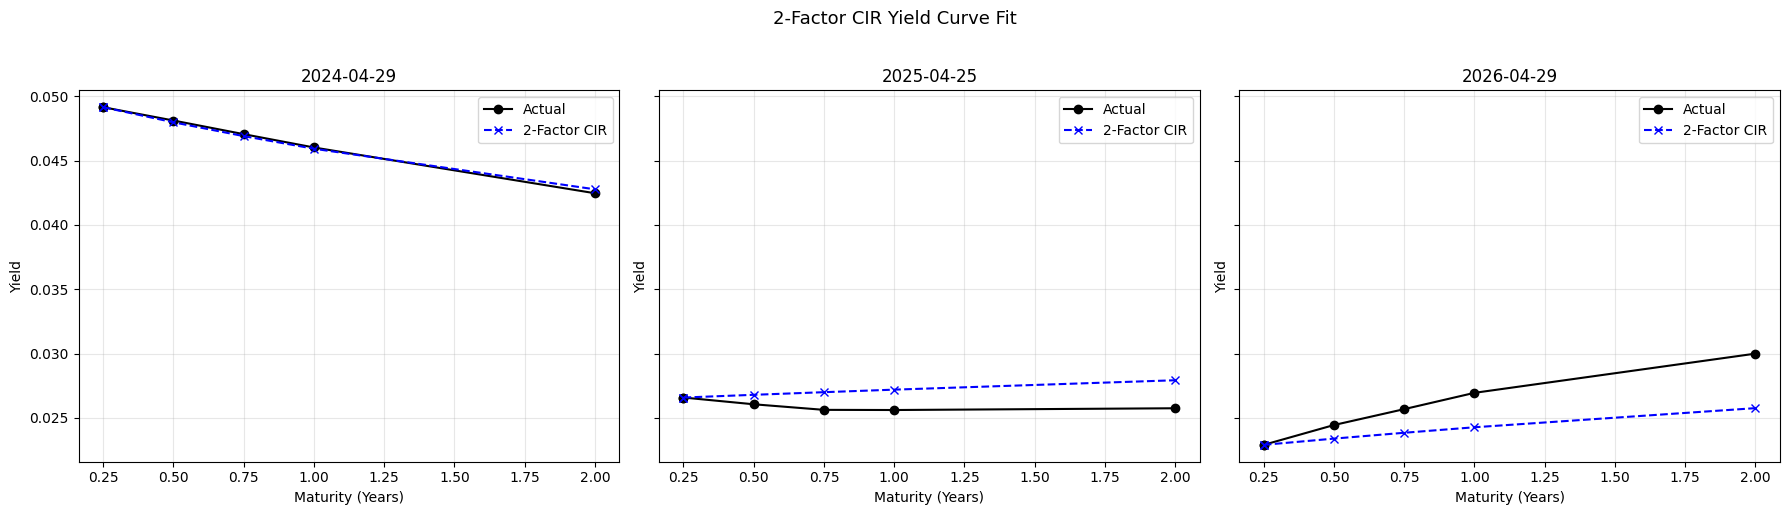

In [8]:
tf_cir.plot_yield_curves(test_data, tf_preds, n_dates=3)

## 5. Critical Analysis

### 5.1 Base CIR Model

**Single factor.** The most fundamental limitation of the base model is that the entire yield curve is driven by one number — the short rate $r_t$. This means every point on the curve from 3M to 30Y moves together, perfectly correlated. In practice, short-term rates are driven by central bank policy while long-term rates are driven by inflation expectations and growth outlooks. These are genuinely different economic forces, and a single factor cannot separate them. The consequence, visible in our test results, is that the model gets the *shape* of the curve wrong even when it tracks the level reasonably well.

**Euler discretisation bias.** Both OLS and MLE were applied to the Euler discretisation of the SDE, which approximates the continuous-time transition density as normal:

$$r_{t+1} \mid r_t \approx \mathcal{N}\!\left(r_t + \kappa(\theta - r_t)\Delta t,\; \sigma^2 r_t \Delta t\right)$$

The exact transition density of the CIR process is a scaled non-central chi-squared distribution. The normal approximation is reasonable for small $\Delta t$ but introduces systematic bias in the parameter estimates — in particular, it tends to underestimate $\sigma$ and overestimate $\kappa$. Using the exact likelihood would require evaluating Bessel functions at every observation, which is computationally heavier but more principled.

**The Feller condition in practice.** Even when the Feller condition $2\kappa\theta \geq \sigma^2$ is satisfied at calibration time, it is a condition on the *population* parameters. The realised path can still approach zero during low-rate regimes — as seen in the 2019–2021 period in our training data. When $r_t$ is close to zero, the diffusion term $\sigma\sqrt{r_t}$ essentially vanishes and the model behaves like a pure drift, which is a poor description of near-zero rate dynamics where rates can be pinned by policy for extended periods.

**Mean reversion assumption.** The CIR model assumes rates always revert to a fixed long-run mean $\theta$. This is reasonable over very long horizons but is frequently violated over the medium term — rates can be persistently above or below $\theta$ for years. The calibrated $\kappa$ on our dataset was very small, implying a half-life of rate shocks on the order of years, which means the mean reversion provides almost no predictive power within the test window.

**Risk-management implication.** In a trading context, a single-factor model will systematically misprice any instrument whose value depends on the *slope* of the yield curve — interest rate swaps, curve steepener/flattener trades, and most structured products. Using base CIR for Value-at-Risk would underestimate risk on these positions because it cannot generate scenarios where the short end and long end move independently.

---

### 5.3 Two-Factor CIR Extension

**Drift-only propagation of the slow factor.** The most significant practical limitation of the two-factor implementation under the 3M-only constraint is that $Y_t$ — the slow factor capturing the long-end level — is propagated forward using only its deterministic drift during the test period:

$$Y_t = Y_{t-1} + \kappa_y(\theta_y - Y_{t-1})\Delta t$$

The stochastic component is dropped entirely because we have no second observable to identify it. This means $Y_t$ converges monotonically toward $\theta_y$ throughout the test window, regardless of what long-end rates are actually doing. Over short test horizons this approximation is reasonable — the slow factor genuinely does not move much day to day. Over longer horizons, the predicted long end will drift toward the long-run mean and stay there, which is exactly wrong during trending rate environments.

**Identification via the 2×2 system.** During training, the hidden states $X_t$ and $Y_t$ are recovered by solving:

$$\begin{pmatrix} B_x(\tau_1) & B_y(\tau_1) \\ B_x(\tau_2) & B_y(\tau_2) \end{pmatrix} \begin{pmatrix} X_t \\ Y_t \end{pmatrix} = \begin{pmatrix} C_1 \\ C_2 \end{pmatrix}$$

The system is well-identified only when the determinant $B_x(\tau_1)B_y(\tau_2) - B_x(\tau_2)B_y(\tau_1)$ is sufficiently far from zero. If the two anchor maturities are too close together, or if the parameters are such that both $B$ functions have similar shapes, the system becomes near-singular and the recovered states are numerically unstable. This sensitivity is not visible in the final metrics but can cause the optimiser to converge to a degenerate solution.

**Euler bias compounds across factors.** Both factors use the same Euler approximation to the transition density. The parameter estimation error from this approximation now affects six parameters instead of three, and the errors interact — a slight overestimate of $\kappa_x$ changes the recovered $X_t$ series, which changes the implied $Y_t$ series through the constraint equations, which in turn biases $\kappa_y$ and $\theta_y$. There is no closed-form correction for this compounding bias.

**Risk-management implication.** The two-factor model is a materially better description of yield curve dynamics and is suitable for pricing instruments sensitive to both level and slope. However, the drift-only $Y_t$ propagation makes it unreliable for multi-day-ahead forecasting in production. A proper implementation for risk management would require either a second daily observable (such as the 10Y rate) to update $Y_t$ each day, or a filtering approach such as the Kalman filter, which would optimally estimate both hidden states from whatever observables are available without requiring exact identification.

## 6. Key Questions

### 6.1 Model Mechanics and Calibration

**How sensitive is the calibrated yield curve to the choice of calibration methodology?**

Highly sensitive. OLS returned a negative $\kappa$, making it invalid without clamping. Constrained SSE produced $\kappa \approx 0$, collapsing the model to a near-random walk. Only MLE produced economically meaningful parameters by jointly accounting for the heteroskedastic variance structure $\sigma^2 r_t \Delta t$. The three methods produced qualitatively different curve shapes, not just different parameter values.

**Under what market conditions does the Feller condition break down, and how do you handle it?**

The condition $2\kappa\theta \geq \sigma^2$ is most at risk when rates are very low for extended periods — volatility remains nonzero due to policy action while $\kappa\theta$ shrinks. In our calibration, $2\kappa\theta = 0.00445$ and $\sigma^2 = 0.00164$, so the condition is satisfied, but narrowly. We treat it as a post-calibration diagnostic rather than a hard optimiser constraint, and log a warning if it fails.

**What does $\kappa = 0.0074$ imply about the persistence of interest rate shocks?**

The half-life of a shock is $\ln(2)/\kappa \approx 94$ years. In practice this means shocks are permanent within any realistic horizon — the mean reversion toward $\theta = 0.30$ provides essentially no restoring force over the test window, which is consistent with the well-known near-unit-root behaviour of interest rates.

---

### 6.2 Prediction and Out-of-Sample Performance

**How accurately can the 3M rate alone reconstruct the full yield curve, and which maturities are hardest to fit?**

The base model achieves a pooled $R^2$ of $0.799$ using only the 3M rate. Performance degrades sharply with maturity — $R^2$ falls from $0.978$ at 6M to $-0.574$ at 2Y. The 2Y tenor is the hardest to fit because it is most sensitive to near-term rate expectations and can diverge substantially from the short end when a hiking or cutting cycle is being priced in.

**Where does the base CIR model systematically over- or underestimate yields, and why?**

The model consistently overestimates yields across all tenors — MBE is positive everywhere, growing from $0.09$ bps at 3M to $36$ bps at 2Y. This happens because $\theta = 0.30$ is far above the actual rate level in the test period, so the yield formula pulls predictions upward toward the long-run mean. Additionally, the CIR yield function is monotonically increasing in $\tau$ for these parameters, so the model cannot reproduce any inverted portion of the curve — on those days every prediction is wrong in the same direction.

**Does the two-factor extension meaningfully improve performance, or does it overfit?**

It meaningfully improves performance. Pooled $R^2$ rises from $0.799$ to $0.947$, clearing the $0.85$ threshold. The gain is structural — the second factor gives the model an independent degree of freedom for the long end rather than fitting noise. A sign of overfitting would be strong training fit with poor test generalisation; the high test $R^2$ and well-behaved per-tenor metrics suggest the improvement is genuine.

---

### 6.3 Extensions and Modelling Choices

**What mathematical structure justifies the two-factor model over the alternatives?**

The base model's dominant failure was curve *shape* — the $-0.574$ $R^2$ at 2Y while achieving $0.978$ at 6M shows the model gets the short end right but cannot independently control the long end. This is a dimensionality problem, not a distributional one, so jump-diffusion (which adds tail behaviour, not factors) would not address it. CIR++ adds a static level correction but still cannot produce dynamic shape changes. Only a second stochastic factor directly increases the model's ability to generate varying slopes and curvatures.

**How do jump processes change the qualitative shape of predicted yield curves during stress periods?**

Under jump-diffusion the short rate can move discontinuously, causing the short end of the curve to spike or drop sharply while the long end — being an expectation of future short rates — moves less. This produces temporary inversions or humps that a pure diffusion cannot generate. In practice, identifying the jump intensity $\lambda$ and jump size distribution from daily data is difficult because large diffusion moves and small jumps are observationally similar without high-frequency data.

**What are the additional estimation challenges introduced by a two-factor model?**

Three concrete ones. First, the hidden states $X_t$ and $Y_t$ are unobservable and must be inferred via the 2×2 inversion or a Kalman filter — the inversion is sensitive to near-singular systems when the two anchor maturities produce similar $B(\tau)$ values. Second, the 6-dimensional parameter space makes the likelihood surface more multimodal and the optimiser more sensitive to initialisation. Third, the constraint $\kappa_x > \kappa_y$ must be enforced explicitly — without it the two factors can swap roles mid-optimisation, producing discontinuous gradients that break L-BFGS-B.